# Эксперимент 10: Улучшенная синтетика + разморозка backbone (DPT)

**Гипотеза:** Синтетика в Эксп.3 и Эксп.6 ухудшала результат, потому что backbone был заморожен и не мог адаптироваться к copy-paste артефактам. При разморозке блоков 8-11 backbone обучается воспринимать синтетические текстуры, что должно дать прирост на редких классах 1 и 2.

**Что изменилось в генерации синтетики (vs Эксп.3/6):**
- Убрана склейка двух патчей (`stitch_defects`) — она создавала неестественные формы
- Вставляется один дефект с мягким альфа-блендингом по краю маски (Gaussian blur)
- Яркость патча подгоняется под фон в месте вставки

| | Эксп.7 | Эксп.9 | **Эксп.10** |
|---|---|---|---|
| Backbone | Заморожен | Разморожен (4 блока) | **Разморожен (4 блока)** |
| Синтетика | Нет | Нет | **Да (улучшенная)** |
| Декодер | DPT 2.8М | DPT 2.8М | **DPT 2.8М** |
| Вход | 224×1400 | 224×1400 | **224×1400** |

> **v2** — исправлен баг: `JointTransform` применяет flip и crop **одновременно** к изображению и маске.

## 1. Импорты и конфигурация

In [1]:
import os, random, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tqdm import tqdm
from collections import Counter
from scipy.ndimage import gaussian_filter
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchmetrics import JaccardIndex
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

print(f'PyTorch: {torch.__version__}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} Гб')

DATA_DIR      = 'C:/Users/ADMIN/Desktop/magistr/VKR/steel_defect/'
TRAIN_CSV     = os.path.join(DATA_DIR, 'train.csv')
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train_images/')
save_dir      = 'C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads'
os.makedirs(save_dir, exist_ok=True)

IMG_H       = 224
IMG_W       = 1400
PATCH_SIZE  = 14
PATCH_H     = IMG_H // PATCH_SIZE   # 16
PATCH_W     = IMG_W // PATCH_SIZE   # 100
MASK_H      = PATCH_H * 4          # 64
MASK_W      = PATCH_W * 4          # 400
EMBED_DIM   = 768
NUM_CLASSES = 5

INTERMEDIATE_LAYERS = [3, 5, 8, 11]

N_UNFREEZE  = 4
LR_BACKBONE = 1e-5
LR_HEAD     = 1e-3
BATCH_SIZE  = 2
EPOCHS      = 75
N_SELECT    = 200
TEST_SIZE   = 0.2
SYNTH_WEIGHT = 0.5   # вес лосса на синтетических примерах

print(f'\nВход:              {IMG_H}x{IMG_W}')
print(f'Слои DPT:          {INTERMEDIATE_LAYERS}')
print(f'Разморожено блоков: {N_UNFREEZE} (блоки {12-N_UNFREEZE}-11)')
print(f'LR backbone/head:  {LR_BACKBONE} / {LR_HEAD}')
print(f'Batch size:        {BATCH_SIZE}')
print(f'Synth loss weight: {SYNTH_WEIGHT}')

PyTorch: 2.12.0.dev20260408+cu128
Устройство: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
VRAM: 8.5 Гб

Вход:              224x1400
Слои DPT:          [3, 5, 8, 11]
Разморожено блоков: 4 (блоки 8-11)
LR backbone/head:  1e-05 / 0.001
Batch size:        2
Synth loss weight: 0.5


## 2. Данные и вспомогательные функции

In [2]:
train_df    = pd.read_csv(TRAIN_CSV)
labeled_ids = train_df['ImageId'].unique().tolist()
print(f'Строк: {len(train_df):,}  |  Изображений: {len(labeled_ids):,}')


def decode_rle(rle_string, shape=(256, 1600)):
    if pd.isna(rle_string) or not isinstance(rle_string, str):
        return np.zeros(shape, dtype=np.uint8)
    nums   = list(map(int, rle_string.strip().split()))
    starts = np.array(nums[0::2]) - 1
    lens   = np.array(nums[1::2])
    mask   = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    for s, l in zip(starts, lens):
        mask[s:s+l] = 1
    return mask.reshape(shape, order='F')


def build_segmask(image_id, df, shape=(256, 1600)):
    mask = np.zeros(shape, dtype=np.uint8)
    for _, row in df[df['ImageId'] == image_id].iterrows():
        cls = int(row['ClassId'])
        m   = decode_rle(row['EncodedPixels'], shape)
        mask[m == 1] = cls
    return mask


def get_classes(img_id, df):
    rows = df[df['ImageId'] == img_id]
    return sorted(rows['ClassId'].dropna().astype(int).unique().tolist())


def get_label(img_id, df):
    cls = get_classes(img_id, df)
    return cls[0] if cls else 0


def compute_class_weights(image_ids, df, num_classes=NUM_CLASSES):
    px = Counter({c: 0 for c in range(num_classes)})
    for img_id in image_ids:
        mask = build_segmask(img_id, df)
        for c in range(num_classes):
            px[c] += int((mask == c).sum())
    total = sum(px.values())
    w = torch.tensor([total/(num_classes*(px[c]+1e-6)) for c in range(num_classes)])
    w = (w / w.mean()).clamp(min=0.1, max=5.0)
    print('Веса классов:')
    for c, v in enumerate(w):
        print(f'  {"Фон" if c==0 else f"Дефект {c}"}: {v:.3f}  ({px[c]:,} пикс.)')
    return w.to(DEVICE)


print('Функции определены.')

Строк: 7,095  |  Изображений: 6,666
Функции определены.


## 3. Dataset (с поддержкой синтетики)

In [3]:
FLIP_P      = 0.5
CROP_SCALE  = (0.85, 1.0)
BRIGHTNESS  = 0.3


class JointTransform:
    def __init__(self, img_h=IMG_H, img_w=IMG_W, is_train=True,
                 flip_p=FLIP_P, crop_scale=CROP_SCALE, brightness=BRIGHTNESS):
        self.img_h       = img_h
        self.img_w       = img_w
        self.is_train    = is_train
        self.flip_p      = flip_p
        self.crop_scale  = crop_scale
        self.color_jitter = transforms.ColorJitter(brightness=brightness)
        self.to_tensor   = transforms.ToTensor()
        self.normalize   = transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __call__(self, img_pil, mask_np):
        img_pil  = img_pil.resize((self.img_w, self.img_h), Image.BILINEAR)
        mask_pil = Image.fromarray(mask_np).resize(
            (self.img_w, self.img_h), Image.NEAREST)
        if self.is_train:
            if random.random() < self.flip_p:
                img_pil  = img_pil.transpose(Image.FLIP_LEFT_RIGHT)
                mask_pil = mask_pil.transpose(Image.FLIP_LEFT_RIGHT)
            scale  = random.uniform(*self.crop_scale)
            crop_h = max(1, int(self.img_h * scale))
            crop_w = max(1, int(self.img_w * scale))
            top    = random.randint(0, self.img_h - crop_h)
            left   = random.randint(0, self.img_w - crop_w)
            img_pil  = img_pil.crop((left, top, left+crop_w, top+crop_h))
            mask_pil = mask_pil.crop((left, top, left+crop_w, top+crop_h))
            img_pil  = img_pil.resize((self.img_w, self.img_h), Image.BILINEAR)
            mask_pil = mask_pil.resize((self.img_w, self.img_h), Image.NEAREST)
            img_pil  = self.color_jitter(img_pil)
        img_t    = self.normalize(self.to_tensor(img_pil))
        mask_np2 = np.array(mask_pil, dtype=np.uint8)
        return img_t, mask_np2


train_jt = JointTransform(is_train=True)
val_jt   = JointTransform(is_train=False)


class SteelSegDataset(Dataset):
    def __init__(self, ids, img_dir, df, joint_transform):
        self.ids=ids; self.img_dir=img_dir
        self.df=df; self.jt=joint_transform
    def __len__(self): return len(self.ids)
    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img    = Image.open(os.path.join(self.img_dir, img_id)).convert('RGB')
        mask   = build_segmask(img_id, self.df)
        img_t, mask_np = self.jt(img, mask)
        mask_t = torch.from_numpy(mask_np).unsqueeze(0).float()
        mask_t = F.interpolate(
            mask_t.unsqueeze(0), size=(MASK_H, MASK_W),
            mode='nearest').squeeze().long()
        return img_t, mask_t, 0   # 0 = реальное изображение


class SteelSegDatasetWithSynth(Dataset):
    def __init__(self, real_ids, img_dir, df, joint_transform, synth_pairs):
        self.real_ids = real_ids
        self.img_dir  = img_dir
        self.df       = df
        self.jt       = joint_transform
        self.synth    = synth_pairs
        self.n_real   = len(real_ids)
        self.n_synth  = len(synth_pairs)
    def __len__(self):
        return self.n_real + self.n_synth
    def __getitem__(self, idx):
        if idx < self.n_real:
            img_id   = self.real_ids[idx]
            img      = Image.open(os.path.join(self.img_dir, img_id)).convert('RGB')
            mask     = build_segmask(img_id, self.df)
            is_synth = 0
        else:
            img_np, mask = self.synth[idx - self.n_real]
            img          = Image.fromarray(img_np.astype(np.uint8))
            is_synth     = 1
        img_t, mask_np = self.jt(img, mask)
        mask_t = torch.from_numpy(mask_np).unsqueeze(0).float()
        mask_t = F.interpolate(
            mask_t.unsqueeze(0), size=(MASK_H, MASK_W),
            mode='nearest').squeeze().long()
        return img_t, mask_t, is_synth


print(f'JointTransform + Datasets определены. Маска: {MASK_H}x{MASK_W}')
print(f'Аугментации: flip_p={FLIP_P}, crop={CROP_SCALE}, brightness={BRIGHTNESS}')

JointTransform + Datasets определены. Маска: 64x400
Аугментации: flip_p=0.5, crop=(0.85, 1.0), brightness=0.3


## 4. Загрузка DINOv2 — частичная разморозка (блоки 8-11)

In [4]:
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14',
                        pretrained=True, verbose=False)
dinov2 = dinov2.to(DEVICE)

for p in dinov2.parameters():
    p.requires_grad = False

n_blocks      = len(dinov2.blocks)       # 12
unfreeze_from = n_blocks - N_UNFREEZE    # 8

for i, block in enumerate(dinov2.blocks):
    if i >= unfreeze_from:
        for p in block.parameters():
            p.requires_grad = True

for p in dinov2.norm.parameters():
    p.requires_grad = True

frozen    = sum(p.numel() for p in dinov2.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in dinov2.parameters() if p.requires_grad)
print(f'DINOv2 ViT-B/14: {(frozen+trainable)/1e6:.1f}М параметров')
print(f'  Заморожено:  {frozen/1e6:.1f}М  (блоки 0-{unfreeze_from-1})')
print(f'  Разморожено: {trainable/1e6:.1f}М  (блоки {unfreeze_from}-{n_blocks-1} + norm)')

with torch.no_grad():
    test_img = torch.randn(1, 3, IMG_H, IMG_W).to(DEVICE)
    feats = dinov2.get_intermediate_layers(
        test_img, n=INTERMEDIATE_LAYERS, return_class_token=False)
    assert all(f.shape == (1, PATCH_H*PATCH_W, EMBED_DIM) for f in feats)
    print(f'Проверка forward: OK  ({len(feats)} слоёв x {feats[0].shape})')
del test_img, feats

C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 ViT-B/14: 86.6М параметров
  Заморожено:  58.2М  (блоки 0-7)
  Разморожено: 28.4М  (блоки 8-11 + norm)
Проверка forward: OK  (4 слоёв x torch.Size([1, 1600, 768]))


## 5. Эмбеддинги (из кэша)

In [5]:
emb_cache = os.path.join(save_dir, 'embeddings.pt')
if os.path.exists(emb_cache):
    print('Загружаем из кэша...')
    ckpt       = torch.load(emb_cache, map_location='cpu')
    embeddings = ckpt['embeddings']
    emb_ids    = ckpt['emb_ids']
    print(f'Загружено: {embeddings.shape}')
else:
    print('Кэш не найден — извлекаем...')
    sq_t = transforms.Compose([
        transforms.Resize((518, 518)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    class _EmbDs(Dataset):
        def __init__(self, ids, d, t): self.ids=ids; self.d=d; self.t=t
        def __len__(self): return len(self.ids)
        def __getitem__(self, i):
            img = Image.open(os.path.join(self.d, self.ids[i])).convert('RGB')
            return self.t(img), self.ids[i]
    ds = _EmbDs(labeled_ids, TRAIN_IMG_DIR, sq_t)
    dl = DataLoader(ds, batch_size=16, shuffle=False, num_workers=0)
    embs, ids_out = [], []
    dinov2.eval()
    with torch.no_grad():
        for imgs, img_ids in tqdm(dl, desc='Эмбеддинги'):
            tok = dinov2.forward_features(imgs.to(DEVICE))['x_norm_clstoken']
            embs.append(tok.cpu()); ids_out.extend(img_ids)
    embeddings = torch.cat(embs, 0); emb_ids = ids_out
    torch.save({'embeddings': embeddings, 'emb_ids': emb_ids}, emb_cache)
    print(f'Сохранено: {embeddings.shape}')

Загружаем из кэша...
Загружено: torch.Size([6666, 768])


## 6. Отбор 200 изображений

In [6]:
def lightly_active_select(embeddings, image_ids, n_select, seed=SEED):
    km = KMeans(n_clusters=n_select, random_state=seed, n_init=10)
    km.fit(embeddings.numpy())
    sel = []
    for k in range(n_select):
        m  = km.labels_ == k
        if not m.any(): continue
        c  = torch.tensor(km.cluster_centers_[k])
        ix = np.where(m)[0]
        sel.append(int(ix[torch.norm(embeddings[m]-c, dim=1).argmin().item()]))
    return [image_ids[i] for i in sel], sel


def stratified_active_select(embeddings, image_ids, classes_cache,
                              n_per_class=50, n_total=N_SELECT):
    image_id_to_idx = {v: k for k, v in enumerate(image_ids)}
    guaranteed = []
    for cls in [1, 2, 3, 4]:
        cids = [i for i in image_ids if cls in classes_cache.get(i, [])]
        guaranteed.extend(random.sample(cids, min(n_per_class, len(cids))))
    guaranteed = list(set(guaranteed))
    remaining  = [i for i in image_ids if i not in guaranteed]
    n_km       = n_total - len(guaranteed)
    extra      = []
    if n_km > 0 and remaining:
        rm    = [image_id_to_idx[i] for i in remaining]
        extra, _ = lightly_active_select(embeddings[rm], remaining, n_km)
    result = guaranteed + extra
    print(f'Отбор: {len(guaranteed)} гарант. + {len(extra)} KMeans = {len(result)}')
    return result


label_map = train_df.groupby('ImageId')['ClassId'].apply(
    lambda x: int(sorted(x.dropna().astype(int).tolist())[0]) if len(x) > 0 else 0
).to_dict()
all_labels = [label_map.get(i, 0) for i in labeled_ids]

train_ids, test_ids = train_test_split(
    labeled_ids, test_size=TEST_SIZE, stratify=all_labels, random_state=SEED)
print(f'Train pool: {len(train_ids):,}  |  Test: {len(test_ids):,}')

classes_cache = train_df.groupby('ImageId')['ClassId'].apply(
    lambda x: sorted(x.dropna().astype(int).unique().tolist())
).to_dict()

emb_id_to_idx = {v: k for k, v in enumerate(emb_ids)}
pool_mask     = [emb_id_to_idx[i] for i in train_ids]
pool_embeds   = embeddings[pool_mask]
selected_ids  = stratified_active_select(
    pool_embeds, train_ids, classes_cache, n_per_class=50, n_total=N_SELECT)
print(f'Итого: {len(selected_ids)}')

Train pool: 5,332  |  Test: 1,334
Отбор: 199 гарант. + 1 KMeans = 200
Итого: 200


## 7. Архитектура: SegHeadDPT (та же, что Эксп.7/9)

In [7]:
class SegHeadDPT(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
                 patch_h=PATCH_H, patch_w=PATCH_W, n_layers=4):
        super().__init__()
        self.patch_h  = patch_h
        self.patch_w  = patch_w
        self.n_layers = n_layers
        self.proj = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(embed_dim, 256, 1),
                nn.BatchNorm2d(256), nn.GELU(),
            ) for _ in range(n_layers)
        ])
        self.fuse = nn.Sequential(
            nn.Conv2d(256 * n_layers, 512, 1),
            nn.BatchNorm2d(512), nn.GELU(),
            nn.Conv2d(512, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.GELU(),
        )
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.GELU(),
        )
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.GELU(),
        )
        self.head = nn.Conv2d(64, num_classes, 1)

    def forward(self, features):
        maps = []
        for i, f in enumerate(features):
            B, N, C = f.shape
            x = f.reshape(B, self.patch_h, self.patch_w, C).permute(0,3,1,2)
            maps.append(self.proj[i](x))
        x = torch.cat(maps, dim=1)
        x = self.fuse(x)
        x = self.up1(x)
        x = self.up2(x)
        return self.head(x)


class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__(); self.s=smooth
    def forward(self, logits, targets):
        p       = F.softmax(logits, dim=1)
        B,C,H,W = p.shape
        t       = F.one_hot(targets, C).permute(0,3,1,2).float()
        i       = (p*t).sum(dim=(2,3))
        u       = p.sum(dim=(2,3)) + t.sum(dim=(2,3))
        return 1 - ((2*i+self.s)/(u+self.s)).mean()


_h = SegHeadDPT().to(DEVICE)
print(f'SegHeadDPT: {sum(p.numel() for p in _h.parameters()):,} параметров')
del _h

SegHeadDPT: 2,845,381 параметров


## 8. Улучшенная генерация синтетики

**Что изменилось по сравнению с Эксп.3/6:**
- Один дефект вместо двух склеенных
- Мягкий альфа-блендинг по краю (Gaussian blur на маске)
- Подгонка яркости патча под фон в месте вставки

In [8]:
def extract_defect_patch(img_id, df, img_dir, cls):
    """Вырезает bounding box дефекта с оригинальными цветами."""
    img  = np.array(Image.open(os.path.join(img_dir, img_id)).convert('RGB'))
    mask = build_segmask(img_id, df)
    px   = np.where(mask == cls)
    if len(px[0]) < 5:
        return None, None
    y0, y1 = px[0].min(), px[0].max()
    x0, x1 = px[1].min(), px[1].max()
    return img[y0:y1+1, x0:x1+1].copy(), mask[y0:y1+1, x0:x1+1].copy()


def paste_defect_smooth(bg_img, bg_mask, patch_img, patch_mask, cls,
                        blur_sigma=3.0, max_attempts=50):
    """
    Вставляет один дефект на реальный фон с мягким блендингом.
    - blur_sigma: радиус размытия маски для альфа-блендинга
    - Яркость патча согласовывается с фоном в месте вставки
    """
    H, W = bg_img.shape[:2]
    h, w = patch_img.shape[:2]
    defect_px = (patch_mask == cls)
    if defect_px.sum() < 5 or h >= H or w >= W:
        return bg_img, bg_mask

    # Мягкая маска: Gaussian blur бинарной маски дефекта
    soft_mask = gaussian_filter(defect_px.astype(float), sigma=blur_sigma)
    soft_mask = np.clip(soft_mask, 0, 1)[:, :, np.newaxis]  # [h, w, 1]

    for _ in range(max_attempts):
        y = random.randint(0, H - h - 1)
        x = random.randint(0, W - w - 1)

        # Место должно быть свободно от дефектов
        if not np.all(bg_mask[y:y+h, x:x+w][defect_px] == 0):
            continue

        bg_region = bg_img[y:y+h, x:x+w].astype(float)
        src       = patch_img.astype(float)

        # Подгоняем яркость патча под фон в зоне дефекта
        src_mean = src[defect_px].mean() + 1e-6
        dst_mean = bg_region[defect_px].mean() + 1e-6
        factor   = np.clip(dst_mean / src_mean, 0.7, 1.3)
        src      = np.clip(src * factor, 0, 255)

        # Альфа-блендинг
        blended = (src * soft_mask + bg_region * (1.0 - soft_mask)).astype(np.uint8)

        ri = bg_img.copy()
        rm = bg_mask.copy()
        ri[y:y+h, x:x+w] = blended
        rm[y:y+h, x:x+w][defect_px] = cls
        return ri, rm

    return bg_img, bg_mask


def generate_synthetic(selected_ids, all_ids, df, img_dir,
                        target_pixels, cls_list=[1, 2]):
    """Генерирует синтетику (один дефект на фон) пока не достигнет target_pixels."""
    sources = {c: [i for i in selected_ids
                   if c in get_classes(i, df)] for c in cls_list}
    for c in cls_list:
        print(f'  Источников класса {c}: {len(sources[c])}')

    synth = []; total_px = 0; n_gen = 0; n_skip = 0
    print(f'Цель: {target_pixels:,} пикселей по классам {cls_list}')

    while total_px < target_pixels:
        cls = random.choice(cls_list)
        if not sources[cls]:
            continue

        bg_id  = random.choice(all_ids)
        bg_img = np.array(Image.open(os.path.join(img_dir, bg_id)).convert('RGB'))
        bg_msk = build_segmask(bg_id, df)

        src_id = random.choice(sources[cls])
        pi, pm = extract_defect_patch(src_id, df, img_dir, cls)
        if pi is None:
            n_skip += 1; continue

        ri, rm = paste_defect_smooth(bg_img, bg_msk, pi, pm, cls)
        n_px   = int((rm == cls).sum())
        if n_px < 10:
            n_skip += 1; continue

        synth.append((ri, rm)); total_px += n_px; n_gen += 1
        if n_gen % 20 == 0:
            print(f'  {n_gen} изобр. | {total_px:,}/{target_pixels:,}')

    print(f'Готово: {n_gen} изображений, {total_px:,} пикселей (пропущено: {n_skip})')
    return synth


print('Функции синтетики определены.')

Функции синтетики определены.


## 9. Генерация синтетики (или загрузка из кэша)

In [9]:
synth_cache = os.path.join(save_dir, 'synth_pairs_v2.pkl')

if os.path.exists(synth_cache):
    print('Загружаем синтетику из кэша...')
    with open(synth_cache, 'rb') as f:
        synth_pairs = pickle.load(f)
    print(f'Загружено: {len(synth_pairs)} изображений')
else:
    # Цель — столько же пикселей класса 1+2, сколько класса 3 в обучающей выборке
    px_cls3 = sum(
        int((build_segmask(i, train_df) == 3).sum())
        for i in selected_ids
    )
    print(f'Пикселей класса 3 в {N_SELECT} примерах: {px_cls3:,}')
    print(f'Цель синтетики (классы 1+2): {px_cls3:,}\n')

    synth_pairs = generate_synthetic(
        selected_ids=selected_ids,
        all_ids=labeled_ids,
        df=train_df,
        img_dir=TRAIN_IMG_DIR,
        target_pixels=px_cls3,
        cls_list=[1, 2],
    )
    with open(synth_cache, 'wb') as f:
        pickle.dump(synth_pairs, f)
    print(f'Синтетика сохранена: {synth_cache}')

print(f'\nИтого: {N_SELECT} реальных + {len(synth_pairs)} синтетических '
      f'= {N_SELECT + len(synth_pairs)} изображений')

Загружаем синтетику из кэша...
Загружено: 433 изображений

Итого: 200 реальных + 433 синтетических = 633 изображений


## 10. Визуализация синтетики

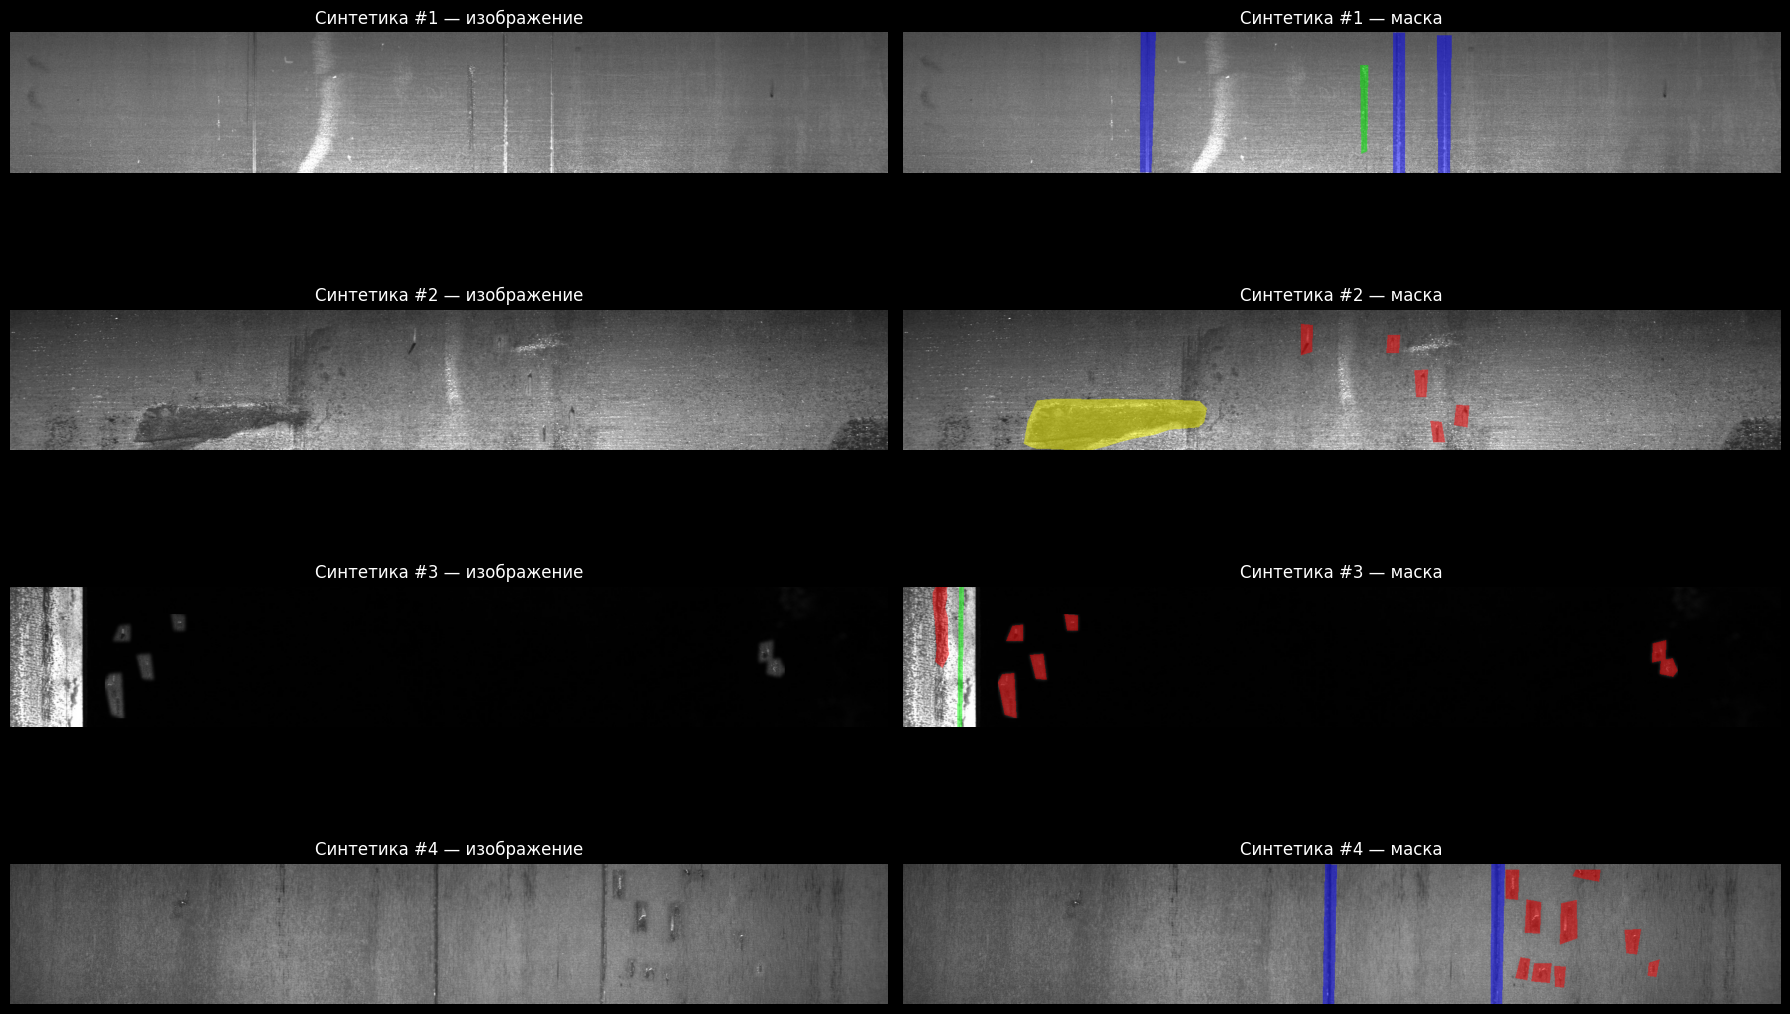

In [10]:
colors = np.array([[0,0,0],[255,0,0],[0,255,0],[0,0,255],[255,255,0]], dtype=np.uint8)
n_show = min(4, len(synth_pairs))
fig, axes = plt.subplots(n_show, 2, figsize=(18, 3*n_show))
if n_show == 1: axes = axes[np.newaxis, :]
for i in range(n_show):
    img_arr, msk = synth_pairs[i]
    overlay = img_arr.copy()
    for c in range(1, NUM_CLASSES):
        overlay[msk == c] = (overlay[msk == c] * 0.5 + colors[c] * 0.5).astype(np.uint8)
    axes[i, 0].imshow(img_arr); axes[i, 0].set_title(f'Синтетика #{i+1} — изображение')
    axes[i, 1].imshow(overlay); axes[i, 1].set_title(f'Синтетика #{i+1} — маска')
    for ax in axes[i]: ax.axis('off')
plt.tight_layout(); plt.show()

## 11. Функция обучения

Отличия от Эксп.9:
- Принимает `synth_pairs` (опционально)
- Синтетические примеры получают вес `SYNTH_WEIGHT` в лоссе

In [11]:
def train_finetune(train_ids, val_ids, df, synth_pairs=None,
                   n_epochs=EPOCHS, label='ft_dpt',
                   checkpoint_every=25):

    head = SegHeadDPT().to(DEVICE)

    backbone_params = [p for p in dinov2.parameters() if p.requires_grad]
    head_params     = list(head.parameters())
    opt = optim.AdamW([
        {'params': backbone_params, 'lr': LR_BACKBONE, 'weight_decay': 1e-2},
        {'params': head_params,     'lr': LR_HEAD,     'weight_decay': 1e-4},
    ])
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    cw    = compute_class_weights(train_ids, df)
    cce   = nn.CrossEntropyLoss(weight=cw, reduction='none')
    cdice = DiceLoss()

    if synth_pairs is not None:
        tds = SteelSegDatasetWithSynth(
            train_ids, TRAIN_IMG_DIR, df, train_jt, synth_pairs)
    else:
        tds = SteelSegDataset(train_ids, TRAIN_IMG_DIR, df, train_jt)

    vds = SteelSegDataset(val_ids, TRAIN_IMG_DIR, df, val_jt)
    tdl = DataLoader(tds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    vdl = DataLoader(vds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    iou  = JaccardIndex(task='multiclass', num_classes=NUM_CLASSES,
                        average='none').to(DEVICE)
    hist = {'train_loss': [], 'val_miou': [], 'val_iou_per_class': []}
    best = 0.0
    best_state_head = None
    best_state_bb   = None

    n_bb = sum(p.numel() for p in backbone_params)
    n_hd = sum(p.numel() for p in head_params)
    print(f'Обучаемых параметров: backbone {n_bb/1e6:.1f}М + head {n_hd/1e3:.0f}К')
    print(f'Обучающих: {len(tds)}  |  Валидационных: {len(vds)}')
    if synth_pairs:
        print(f'  из них реальных: {len(train_ids)}, синтетических: {len(synth_pairs)}')

    for ep in range(1, n_epochs+1):
        dinov2.eval()
        for i, block in enumerate(dinov2.blocks):
            if i >= (12 - N_UNFREEZE):
                block.train()
        dinov2.norm.train()
        head.train()

        tl = 0.0
        for imgs, masks, is_synth in tdl:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            feats = dinov2.get_intermediate_layers(
                imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
            lg = head(feats)

            # Взвешенный лосс: синтетика получает SYNTH_WEIGHT
            pixel_loss = cce(lg, masks)                    # [B, H, W]
            w_batch    = torch.where(
                is_synth.bool().to(DEVICE)[:, None, None],
                torch.full_like(pixel_loss, SYNTH_WEIGHT),
                torch.ones_like(pixel_loss)
            )
            loss = (pixel_loss * w_batch).mean() + 0.5 * cdice(lg, masks)

            opt.zero_grad(); loss.backward(); opt.step()
            tl += loss.item()
        sched.step()

        dinov2.eval(); head.eval(); iou.reset()
        with torch.no_grad():
            for imgs, masks, _ in vdl:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                feats = dinov2.get_intermediate_layers(
                    imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
                iou.update(head(feats).argmax(1), masks)
        ipc = iou.compute().cpu().numpy()
        mi  = float(ipc.mean())
        hist['train_loss'].append(tl/len(tdl))
        hist['val_miou'].append(mi)
        hist['val_iou_per_class'].append(ipc.tolist())

        if mi > best:
            best = mi
            best_state_head = {k: v.clone() for k, v in head.state_dict().items()}
            best_state_bb   = {k: v.clone() for k, v in dinov2.state_dict().items()}

        if ep % 10 == 0 or ep == 1:
            s = '  '.join([f'cls{i}:{v:.3f}' for i, v in enumerate(ipc)])
            print(f'[{label}] Эп {ep:3d}/{n_epochs} | '
                  f'Loss:{tl/len(tdl):.4f} | mIoU:{mi:.4f} | {s}')

        if ep % checkpoint_every == 0:
            ckpt_path = os.path.join(save_dir, f'ckpt_{label}_v2_ep{ep}.pt')
            torch.save({'epoch': ep, 'head_state': head.state_dict(),
                        'backbone_state': dinov2.state_dict(),
                        'history': hist, 'best_miou': best}, ckpt_path)
            print(f'  Чекпоинт: {ckpt_path}')

    head.load_state_dict(best_state_head)
    dinov2.load_state_dict(best_state_bb)
    print(f'\n  -> Лучший mIoU: {best:.4f}')
    return head, hist


print('Функция обучения определена.')

Функция обучения определена.


## 12. Обучение

In [12]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free, total = torch.cuda.mem_get_info()
    used = torch.cuda.memory_allocated()
    print(f'VRAM занято:   {used/1e9:.1f} Гб')
    print(f'VRAM свободно: {free/1e9:.1f} Гб  /  {total/1e9:.1f} Гб всего')

print('='*65)
print(f'ЭКСП.10: {N_SELECT} реал. + {len(synth_pairs)} синт., '
      f'{IMG_H}x{IMG_W}, backbone разморожен ({N_UNFREEZE} блоков)')
print('='*65)
model_synth, history_synth = train_finetune(
    selected_ids, test_ids, train_df,
    synth_pairs=synth_pairs,
    label='ft_dpt_synth'
)

VRAM занято:   0.4 Гб
VRAM свободно: 6.9 Гб  /  8.5 Гб всего
ЭКСП.10: 200 реал. + 433 синт., 224x1400, backbone разморожен (4 блоков)
Веса классов:
  Фон: 0.100  (78,181,311 пикс.)
  Дефект 1: 1.991  (236,225 пикс.)
  Дефект 2: 2.428  (193,649 пикс.)
  Дефект 3: 0.257  (1,832,305 пикс.)
  Дефект 4: 0.318  (1,476,510 пикс.)
Обучаемых параметров: backbone 28.4М + head 2845К
Обучающих: 633  |  Валидационных: 1334
  из них реальных: 200, синтетических: 433
[ft_dpt_synth] Эп   1/75 | Loss:0.4201 | mIoU:0.3992 | cls0:0.942  cls1:0.130  cls2:0.023  cls3:0.443  cls4:0.459
[ft_dpt_synth] Эп  10/75 | Loss:0.1062 | mIoU:0.4739 | cls0:0.956  cls1:0.181  cls2:0.117  cls3:0.524  cls4:0.592
[ft_dpt_synth] Эп  20/75 | Loss:0.0825 | mIoU:0.5112 | cls0:0.944  cls1:0.237  cls2:0.267  cls3:0.467  cls4:0.642
  Чекпоинт: C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads\ckpt_ft_dpt_synth_v2_ep25.pt
[ft_dpt_synth] Эп  30/75 | Loss:0.0715 | mIoU:0.5626 | cls0:0.966  cls1:0.259  cls2:0.389  cls3:0.580  cls4:0.619


## 13. Сравнение

ИТОГОВОЕ СРАВНЕНИЕ:
  Эксп.5 (1 слой)               : mIoU = 0.4219
  Эксп.7 (DPT, замор.)          : mIoU = 0.5248
  Эксп.9 (DPT+разморозка)       : mIoU = 0.5406
  Эксп.10 (DPT+разморозка+синт.): mIoU = 0.5946

  Прирост vs Эксп.9: +5.4%

  Класс         Эксп.5 (1   Эксп.7 (DP  Эксп.9 (DP     Эксп.10
  ------------------------------------------------------------
  Фон               0.9506      0.9597      0.9585      0.9679
  Дефект 1          0.1071      0.2718      0.2938      0.3858
  Дефект 2          0.1095      0.3245      0.3412      0.3949
  Дефект 3          0.4194      0.4925      0.4914      0.5913
  Дефект 4          0.5229      0.5754      0.6183      0.6330


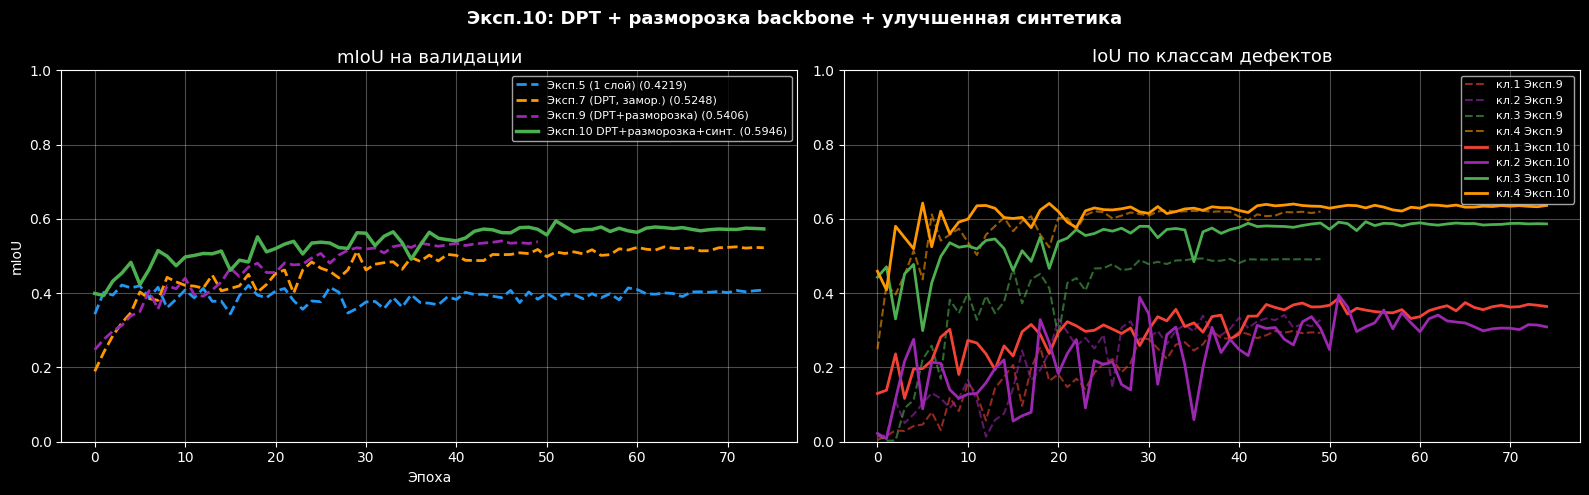

In [13]:
names = ['Фон', 'Дефект 1', 'Дефект 2', 'Дефект 3', 'Дефект 4']

m_s10 = max(history_synth['val_miou'])
e_s10 = int(np.argmax(history_synth['val_miou']))
i_s10 = history_synth['val_iou_per_class'][e_s10]

results = {}
for name, fname in [
    ('Эксп.5 (1 слой)',        'history_ar.json'),
    ('Эксп.7 (DPT, замор.)',   'history_dpt_v2.json'),
    ('Эксп.9 (DPT+разморозка)','history_ft_dpt_v2.json'),
]:
    p = os.path.join(save_dir, fname)
    if os.path.exists(p):
        with open(p) as f:
            h = json.load(f)
        m = max(h['val_miou'])
        e = int(np.argmax(h['val_miou']))
        results[name] = {'miou': m, 'iou': h['val_iou_per_class'][e], 'hist': h}

print('ИТОГОВОЕ СРАВНЕНИЕ:')
for name, r in results.items():
    print(f'  {name:<30}: mIoU = {r["miou"]:.4f}')
print(f'  {"Эксп.10 (DPT+разморозка+синт.)":<30}: mIoU = {m_s10:.4f}')

if 'Эксп.9 (DPT+разморозка)' in results:
    ref = results['Эксп.9 (DPT+разморозка)']
    print(f'\n  Прирост vs Эксп.9: {(m_s10 - ref["miou"])*100:+.1f}%')

print(f'\n  {"Класс":<12}', end='')
for name in results:
    print(f'{name[:10]:>12}', end='')
print(f'{"Эксп.10":>12}')
print('  ' + '-'*(12 + 12*len(results) + 12))
for c in range(NUM_CLASSES):
    print(f'  {names[c]:<12}', end='')
    for r in results.values():
        print(f'{r["iou"][c]:>12.4f}', end='')
    print(f'{i_s10[c]:>12.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

palette = ['#2196F3', '#FF9800', '#9C27B0']
for (name, r), col in zip(results.items(), palette):
    axes[0].plot(r['hist']['val_miou'], color=col, lw=2,
                 label=f'{name} ({r["miou"]:.4f})', ls='--')
axes[0].plot(history_synth['val_miou'], color='#4CAF50', lw=2.5,
             label=f'Эксп.10 DPT+разморозка+синт. ({m_s10:.4f})')
axes[0].set_title('mIoU на валидации', fontsize=13)
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('mIoU')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3); axes[0].set_ylim(0, 1)

cls_colors = {1:'#F44336', 2:'#9C27B0', 3:'#4CAF50', 4:'#FF9800'}
if 'Эксп.9 (DPT+разморозка)' in results:
    h9 = results['Эксп.9 (DPT+разморозка)']['hist']
    for cls, col in cls_colors.items():
        axes[1].plot([h[cls] for h in h9['val_iou_per_class']],
                     color=col, lw=1.5, ls='--', alpha=0.6, label=f'кл.{cls} Эксп.9')
for cls, col in cls_colors.items():
    axes[1].plot([h[cls] for h in history_synth['val_iou_per_class']],
                 color=col, lw=2, label=f'кл.{cls} Эксп.10')
axes[1].set_title('IoU по классам дефектов', fontsize=13)
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3); axes[1].set_ylim(0, 1)

plt.suptitle('Эксп.10: DPT + разморозка backbone + улучшенная синтетика',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 14. Сохранение

In [14]:
torch.save(model_synth.state_dict(),
           os.path.join(save_dir, 'model_ft_dpt_synth_v2.pt'))
torch.save(dinov2.state_dict(),
           os.path.join(save_dir, 'dinov2_finetuned_synth_v2.pt'))
with open(os.path.join(save_dir, 'history_ft_dpt_synth_v2.json'), 'w') as f:
    json.dump(history_synth, f)
print('Сохранено:')
print('  model_ft_dpt_synth.pt      — голова DPT')
print('  dinov2_finetuned_synth.pt  — backbone после fine-tuning')
print('  history_ft_dpt_synth.json  — история обучения')
print(f'\nЛучший mIoU: {m_s10:.4f}')

Сохранено:
  model_ft_dpt_synth.pt      — голова DPT
  dinov2_finetuned_synth.pt  — backbone после fine-tuning
  history_ft_dpt_synth.json  — история обучения

Лучший mIoU: 0.5946
